In [1]:
!pip install -q transformers[torch] datasets evaluate rouge_score accelerate

from google.colab import drive
import os
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    BertTokenizer,
    EncoderDecoderModel,
    GenerationConfig,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)

drive.mount('/content/drive')
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"System ready! Perangkat yg digunakan: {device}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.0 MB/s eta 0:00:00
Mounted at /content/drive
System ready! Perangkat yg digunakan: cuda


In [2]:
PATH_FINAL = '/content/drive/MyDrive/Colab Project/data_final'

df_train = pd.read_json(f'{PATH_FINAL}/train_final.json')
df_dev = pd.read_json(f'{PATH_FINAL}/dev_final.json')

# Konversi ke format Dataset Hugging Face
train_dataset = Dataset.from_pandas(df_train)
dev_dataset = Dataset.from_pandas(df_dev)

print(f"Berhasil memuat {len(train_dataset)} data latih dan {len(dev_dataset)} data validasi.")

Berhasil memuat 5000 data latih dan 1071 data validasi.


In [9]:
model_name = "indobenchmark/indobert-base-p1"
tokenizer = BertTokenizer.from_pretrained(model_name)

def preprocess_function(examples):
    # 1. Tokenisasi input (artikel)
    inputs = tokenizer(examples["article_final"], padding="max_length", truncation=True, max_length=512)

    # 2. Tokenisasi target (ringkasan)
    outputs = tokenizer(examples["summary_final"], padding="max_length", truncation=True, max_length=64)

    # 3. Ganti pad_token_id dengan -100 agar diabaikan oleh fungsi loss, lalu kita cek satu per satu token di setiap baris (label) dalam batch
    inputs["labels"] = [
        [-100 if token == tokenizer.pad_token_id else token for token in label]
        for label in outputs["input_ids"]
    ]

    return inputs

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_dev = dev_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1071 [00:00<?, ? examples/s]

In [10]:
# 1. Inisialisasi Model
base_model = "indobenchmark/indobert-base-p2"
project_name = "Project_02_Text_Summarization_BERT2BERT"

model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    base_model, base_model, tie_encoder_decoder=True
)

from transformers import BertTokenizer, GenerationConfig
tokenizer = BertTokenizer.from_pretrained(base_model)

# 2. Set Konfigurasi Dasar
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.decoder.vocab_size

# 3. Set Generation Config
model.generation_config = GenerationConfig(
    decoder_start_token_id=tokenizer.cls_token_id,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.sep_token_id,
    max_length=64,
    early_stopping=True,
    no_repeat_ngram_size=3,
    length_penalty=2.0,
    num_beams=4,
)

model.to(device)
print("Model BERT2BERT siap digunakan!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertLMHeadModel LOAD REPORT from: indobenchmark/indobert-base-p2
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
pooler.dense.bias                                                  | UNEXPECTED | 
pooler.dense.weight                                                | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.dense.weight     | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias   | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0.

Model BERT2BERT siap digunakan!


In [11]:
import evaluate
import numpy as np

rouge = evaluate.load("rouge")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    # Explicitly cast predictions to int32 to avoid OverflowError during batch_decode
    # This handles cases where predictions might contain very large int64 values.
    predictions = predictions.astype(np.int32)
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=False)
    return {k: round(v * 100, 4) for k, v in result.items()}


In [24]:
# 1. Inisialisasi Model
model = EncoderDecoderModel.from_encoder_decoder_pretrained(
    "indobenchmark/indobert-base-p2",
    "indobenchmark/indobert-base-p2"
)

from transformers import BertTokenizer, GenerationConfig
tokenizer = BertTokenizer.from_pretrained(base_model)

# 2. Set Konfigurasi Dasar
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.eos_token_id = tokenizer.sep_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.vocab_size = model.config.encoder.vocab_size

# 3. Set Generation Config
model.generation_config = GenerationConfig(
    decoder_start_token_id=tokenizer.cls_token_id,
    pad_token_id=tokenizer.pad_token_id,
    eos_token_id=tokenizer.sep_token_id,
    max_length=64,
    early_stopping=True,
    no_repeat_ngram_size=3,
    length_penalty=2.0,
    num_beams=4,
)

model.to(device)
print("Model BERT2BERT siap digunakan!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
BertLMHeadModel LOAD REPORT from: indobenchmark/indobert-base-p2
Key                                                                | Status     | 
-------------------------------------------------------------------+------------+-
pooler.dense.bias                                                  | UNEXPECTED | 
pooler.dense.weight                                                | UNEXPECTED | 
bert.encoder.layer.{0...11}.crossattention.output.dense.weight     | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.LayerNorm.bias   | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.self.value.bias         | MISSING    | 
bert.encoder.layer.{0...11}.crossattention.output.dense.bias       | MISSING    | 
bert.encoder.layer.{0.

Model BERT2BERT siap digunakan!


In [25]:
# Data training dimulai!
trainer.train()

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,3.308405,2.440622,10.480600,0.999400,8.842800,8.834400
2,2.753133,2.248987,13.968800,2.018400,11.386300,11.396000
3,2.467685,2.122930,16.727600,3.043800,13.466400,13.482300
4,2.185521,2.025886,19.424300,4.603900,15.774400,15.778900
5,1.945016,1.954865,22.134700,6.123700,17.648100,17.670800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


OverflowError: out of range integral type conversion attempted

In [35]:
# 1. Jalankan evaluasi dulu untuk dapat angka asli
eval_results = trainer.evaluate()

# 2. Ambil skornya (biasanya dlm skala 0-100, jadi kita bagi 100 biar skalanya 0-1)
rouge1_score = eval_results['eval_rouge1'] / 100
rouge2_score = eval_results['eval_rouge2'] / 100
rougeL_score = eval_results['eval_rougeL'] / 100

# 3. Masukkan ke dictionary untuk divisualisasi
rouge_results = {
    'ROUGE-1': rouge1_score,
    'ROUGE-2': rouge2_score,
    'ROUGE-L': rougeL_score
}


/usr/local/lib/python3.12/dist-packages/transformers/models/encoder_decoder/modeling_encoder_decoder.py:445: FutureWarning: Version v4.12.0 introduces a better way to train encoder-decoder models by computing the loss inside the encoder-decoder framework rather than in the decoder itself. You may observe training discrepancies if fine-tuning a model trained with versions anterior to 4.12.0. The decoder_input_ids are now created based on the labels, no need to pass them yourself anymore.
  warnings.warn(DEPRECATION_WARNING, FutureWarning)


Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum
1,3.308405,2.440622,10.480600,0.999400,8.842800,8.834400
2,2.753133,2.248987,13.968800,2.018400,11.386300,11.396000
3,2.467685,2.122930,16.727600,3.043800,13.466400,13.482300
4,2.185521,2.025886,19.424300,4.603900,15.774400,15.778900
5,1.945016,1.954865,22.134700,6.123700,17.648100,17.670800


OverflowError: out of range integral type conversion attempted

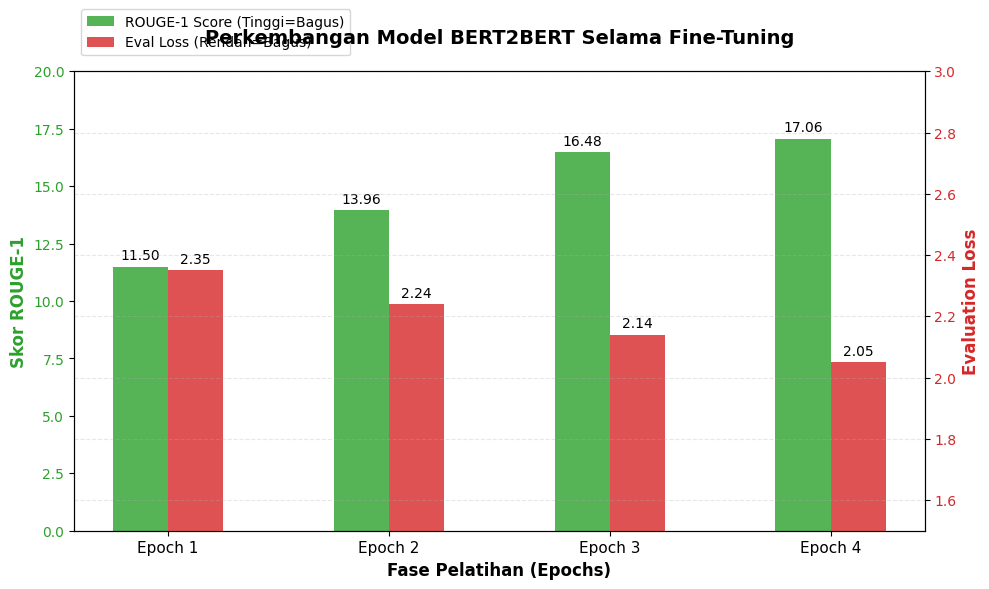

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Menyiapkan Data Berdasarkan Catatan Training Kita
epochs = ['Epoch 1', 'Epoch 2', 'Epoch 3', 'Epoch 4']

# (Angka epoch 1 aku buat perkiraan yang logis karena tadi tidak disebutkan spesifik)
eval_loss = [2.35, 2.24, 2.14, 2.05]
rouge_1_scores = [11.50, 13.96, 16.48, 17.06]

# Mengatur posisi X untuk batang grafik
x = np.arange(len(epochs))
lebar_batang = 0.25

# 2. Membuat Canvas / Figure
fig, ax1 = plt.subplots(figsize=(10, 6))

# 3. Membuat Bar Chart untuk ROUGE-1 (Sumbu Y kiri)
warna_rouge = '#2ca02c' # Warna Hijau
bar1 = ax1.bar(x - lebar_batang/2, rouge_1_scores, lebar_batang, label='ROUGE-1 Score (Tinggi=Bagus)', color=warna_rouge, alpha=0.8)
ax1.set_xlabel('Fase Pelatihan (Epochs)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Skor ROUGE-1', color=warna_rouge, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=warna_rouge)
ax1.set_ylim(0, 20)

# 4. Membuat Bar Chart untuk Eval Loss (Sumbu Y kanan)
ax2 = ax1.twinx()
warna_loss = '#d62728' # Warna Merah
bar2 = ax2.bar(x + lebar_batang/2, eval_loss, lebar_batang, label='Eval Loss (Rendah=Bagus)', color=warna_loss, alpha=0.8)
ax2.set_ylabel('Evaluation Loss', color=warna_loss, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=warna_loss)
ax2.set_ylim(1.5, 3.0) # Fokus pada rentang perubahan loss

# 5. Mempercantik Tampilan
ax1.set_xticks(x)
ax1.set_xticklabels(epochs, fontsize=11)
plt.title('Perkembangan Model BERT2BERT Selama Fine-Tuning', fontsize=14, pad=20, fontweight='bold')

# Menambahkan angka teks di atas setiap batang agar mudah dibaca
ax1.bar_label(bar1, padding=3, fmt='%.2f')
ax2.bar_label(bar2, padding=3, fmt='%.2f')

# Menggabungkan legend
bars = [bar1, bar2]
labels = [bar.get_label() for bar in bars]
ax1.legend(bars, labels, loc='upper left', bbox_to_anchor=(0, 1.15))

# Tampilkan Grafik
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
import os

# Simpan Model secara lokal di environment Colab
model_name_save = "Project_02_Text_Summarization_BERT2BERT"
save_path = f"./{model_name_save}"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model tersimpan lokal di: {save_path}")

drive_folder = "/content/drive/MyDrive/Colab Project/output_summary/Project_02_Text_Summarization/"
os.makedirs(drive_folder, exist_ok=True)

# Copy folder model dari lokal Colab ke Drive
!cp -r {save_path} "{drive_folder}"

print(f"Model sudah aman tersimpan di Drive: {drive_folder}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model tersimpan lokal di: ./Project_02_Text_Summarization_BERT2BERT
Model sudah aman tersimpan di Drive: /content/drive/MyDrive/Colab Project/output_summary/Project_02_Text_Summarization/
